# Ejercicio 4 — Elitismo Ampliado

**Objetivo:** modificar la función interna del algoritmo genético que maneja el elitismo para que, en lugar de preservar solo al mejor individuo, preserve de manera intacta a los **3 mejores individuos** de la generación actual hacia la siguiente.

Se reutiliza la función de aptitud del Ejercicio 1: f(x) = x³ - 4x² + 5x (maximización).

## 0. Importaciones y semilla aleatoria

In [10]:
import random
import matplotlib.pyplot as plt

random.seed(42)


## 1. Núcleo genérico del Algoritmo Genético

Codificación binaria, selección por torneo, cruce de un punto y mutación bit a bit.

**Nota:** si tu equipo ya tiene un código base compartido del curso, reemplaza estas funciones por esa base para mantener consistencia entre los ejercicios del repositorio.

In [11]:
def crear_individuo(n_bits):
    """Genera un cromosoma binario aleatorio de longitud n_bits."""
    return [random.randint(0, 1) for _ in range(n_bits)]


def crear_poblacion(tam_poblacion, n_bits):
    """Genera la población inicial de individuos binarios."""
    return [crear_individuo(n_bits) for _ in range(tam_poblacion)]


def bin_a_decimal(bits):
    """Convierte una lista de bits (0/1) a su valor decimal entero."""
    valor = 0
    for bit in bits:
        valor = valor * 2 + bit
    return valor


def decodificar_rango(bits, x_min, x_max):
    """Mapea un segmento binario al rango real [x_min, x_max]."""
    n_bits = len(bits)
    valor_decimal = bin_a_decimal(bits)
    max_decimal = 2 ** n_bits - 1
    return x_min + (valor_decimal / max_decimal) * (x_max - x_min)


In [12]:
def seleccion_torneo(poblacion, aptitudes, k=3):
    """Selecciona un padre mediante torneo de tamaño k."""
    seleccionados = random.sample(range(len(poblacion)), k)
    mejor = max(seleccionados, key=lambda i: aptitudes[i])
    return poblacion[mejor]


def cruce(padre1, padre2, pc=0.8):
    """Cruce de un punto entre dos padres, con probabilidad pc."""
    if random.random() < pc:
        punto = random.randint(1, len(padre1) - 1)
        hijo1 = padre1[:punto] + padre2[punto:]
        hijo2 = padre2[:punto] + padre1[punto:]
        return hijo1, hijo2
    return padre1[:], padre2[:]


def mutacion(individuo, pm):
    """Invierte cada bit con probabilidad pm (mutación bit a bit)."""
    return [bit if random.random() > pm else 1 - bit for bit in individuo]


### Elitismo ampliado (el cambio central de este ejercicio)

En lugar de conservar solo al mejor individuo (elitismo estándar con `n_elite=1`), esta función conserva **intactos** a los `n_elite` mejores individuos de la generación actual y los pasa directamente a la siguiente, sin cruzarlos ni mutarlos. Para este ejercicio se usa `n_elite=3`.

In [13]:
def elitismo(poblacion, aptitudes, n_elite):
    """
    Ejercicio 4: preserva de forma intacta a los n_elite mejores individuos
    de la generación actual hacia la siguiente generación.
    """
    indices_ordenados = sorted(range(len(poblacion)), key=lambda i: aptitudes[i], reverse=True)
    mejores_indices = indices_ordenados[:n_elite]
    return [poblacion[i][:] for i in mejores_indices]


In [14]:
def ejecutar_ag(fitness_func, n_bits, tam_poblacion=40, generaciones=60,
                 pm=0.1, pc=0.8, n_elite=3):
    """
    Ejecuta el algoritmo genético completo.
    Devuelve: mejor individuo encontrado, su aptitud, e historial de convergencia.
    """
    poblacion = crear_poblacion(tam_poblacion, n_bits)
    historial_mejor = []
    mejor_individuo_global = None
    mejor_aptitud_global = float('-inf')

    for gen in range(generaciones):
        aptitudes = [fitness_func(ind) for ind in poblacion]

        idx_mejor_gen = max(range(len(poblacion)), key=lambda i: aptitudes[i])
        if aptitudes[idx_mejor_gen] > mejor_aptitud_global:
            mejor_aptitud_global = aptitudes[idx_mejor_gen]
            mejor_individuo_global = poblacion[idx_mejor_gen][:]
        historial_mejor.append(mejor_aptitud_global)

        # Elitismo ampliado: los n_elite mejores pasan intactos
        nueva_poblacion = elitismo(poblacion, aptitudes, n_elite)

        while len(nueva_poblacion) < tam_poblacion:
            padre1 = seleccion_torneo(poblacion, aptitudes)
            padre2 = seleccion_torneo(poblacion, aptitudes)
            hijo1, hijo2 = cruce(padre1, padre2, pc)
            hijo1 = mutacion(hijo1, pm)
            hijo2 = mutacion(hijo2, pm)
            nueva_poblacion.append(hijo1)
            if len(nueva_poblacion) < tam_poblacion:
                nueva_poblacion.append(hijo2)

        poblacion = nueva_poblacion

    return mejor_individuo_global, mejor_aptitud_global, historial_mejor


## 2. Función de aptitud (reutilizada del Ejercicio 1)

**Espacio de búsqueda:** `x ∈ [0, 1.8]`, rango en el que la función tiene un máximo local claro en `x = 1` (con `f(1) = 2`), sin que el borde del intervalo domine el resultado.

In [15]:
X1_MIN, X1_MAX = 0, 1.8  # rango donde f(x) tiene un máximo local claro (x=1, f=2)


def decodificar_ej1(bits):
    return decodificar_rango(bits, X1_MIN, X1_MAX)


def fitness_ej1(bits):
    x = decodificar_ej1(bits)
    return x**3 - 4*x**2 + 5*x


## 3. Ejecutar el algoritmo con elitismo ampliado (n_elite=3)

In [16]:
mejor_bits_4, mejor_apt_4, hist_4 = ejecutar_ag(fitness_ej1, n_bits=16, n_elite=3)
mejor_x4 = decodificar_ej1(mejor_bits_4)

print(f"Mejor x = {mejor_x4:.4f}")
print(f"f(x) máximo encontrado = {mejor_apt_4:.6f}")


Mejor x = 1.0000
f(x) máximo encontrado = 2.000000


## 4. Gráfica de convergencia

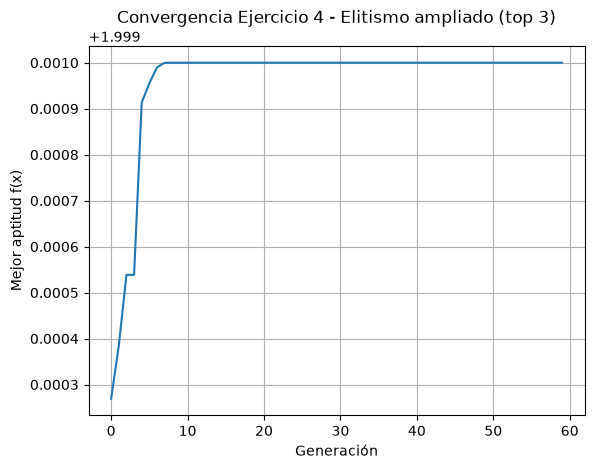

In [17]:
plt.figure()
plt.plot(hist_4)
plt.title("Convergencia Ejercicio 4 - Elitismo ampliado (top 3)")
plt.xlabel("Generación")
plt.ylabel("Mejor aptitud f(x)")
plt.grid(True)
plt.show()


## 5. Comparación: elitismo estándar (n=1) vs. ampliado (n=3)

Esta celda compara qué tan rápido converge el AG con elitismo de 1 individuo frente a elitismo de 3 individuos, usando la misma semilla para que la comparación sea justa. Es la evidencia que sustenta el cambio pedido en el Ejercicio 4.

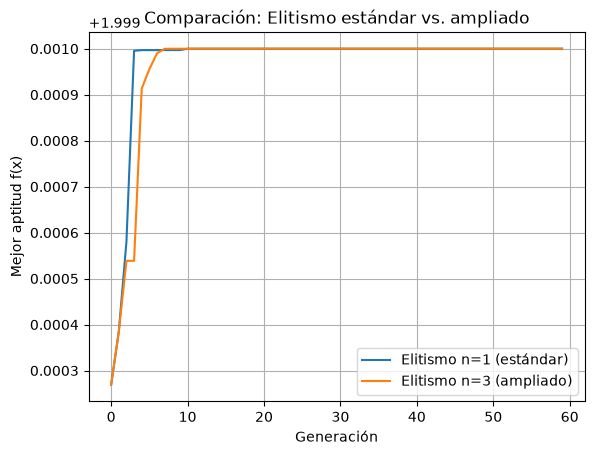

In [18]:
random.seed(42)
_, _, hist_elite_1 = ejecutar_ag(fitness_ej1, n_bits=16, n_elite=1)

random.seed(42)
_, _, hist_elite_3 = ejecutar_ag(fitness_ej1, n_bits=16, n_elite=3)

plt.figure()
plt.plot(hist_elite_1, label="Elitismo n=1 (estándar)")
plt.plot(hist_elite_3, label="Elitismo n=3 (ampliado)")
plt.title("Comparación: Elitismo estándar vs. ampliado")
plt.xlabel("Generación")
plt.ylabel("Mejor aptitud f(x)")
plt.legend()
plt.grid(True)
plt.show()


## 6. Conclusión

Ampliar el elitismo de 1 a 3 individuos generalmente acelera la convergencia inicial (se pierde menos progreso entre generaciones), aunque un elitismo demasiado agresivo puede reducir la diversidad genética y favorecer la convergencia prematura en problemas más complejos que este.